In [45]:
import numpy as np
import matplotlib.pyplot as plt

In [46]:
TIME_Facil = 12
TIME_Complejo = 20
TIME_MuyComplejo = 31
# Minutos laborables por día, 9 a 4 son 7 horas
MIN_Jornada = 7 * 60

In [47]:
def simulate_one_run(num_records: int, rng: np.random.Generator) -> int:
    # 0=F, 1=C, 2=M
    states = np.zeros(num_records, dtype=np.int8)  #todos empiezan en Fácil
    total_minutos = 0
    # Mientras existan registros activos no resueltos
    while states.size > 0:
        counts = np.bincount(states, minlength=3)
        total_minutos += counts[0] * TIME_Facil + counts[1] * TIME_Complejo + counts[2] * TIME_MuyComplejo

        u = rng.random(states.size)

        # Nuevo arreglo para estados no resueltos
        new_states_list = []

        mask_F = (states == 0)
        if mask_F.any():
            uF = u[mask_F]
            toC = (uF >= 0.60) & (uF < 0.90)
            toM = (uF >= 0.90)

            if toC.any():
                new_states_list.append(np.full(toC.sum(), 1, dtype=np.int8))
            if toM.any():
                new_states_list.append(np.full(toM.sum(), 2, dtype=np.int8))

        mask_C = (states == 1)
        if mask_C.any():
            uC = u[mask_C]
            toM = (uC >= 0.90)
            if toM.any():
                new_states_list.append(np.full(toM.sum(), 2, dtype=np.int8))

        mask_M = (states == 2)
        if mask_M.any():
            uM = u[mask_M]
            toF = (uM >= 0.10) & (uM < 0.99)
            toC = (uM >= 0.99)

            if toF.any():
                new_states_list.append(np.full(toF.sum(), 0, dtype=np.int8))
            if toC.any():
                new_states_list.append(np.full(toC.sum(), 1, dtype=np.int8))

        #Unir estados sobrevivientes no resueltos para la siguiente iteración
        if new_states_list:
            states = np.concatenate(new_states_list)
        else:
            states = np.array([], dtype=np.int8)

    return int(total_minutos)

In [48]:
def monte_carlo(num_records: int, n_sims: int = 2000, seed: int = 42):
    rng = np.random.default_rng(seed)
    totals = np.empty(n_sims, dtype=np.int64)

    for i in range(n_sims):
        totals[i] = simulate_one_run(num_records=num_records, rng=rng)

    # Estadísticas
    mean_min = totals.mean()
    p50 = np.percentile(totals, 50)
    p90 = np.percentile(totals, 90)
    p95 = np.percentile(totals, 95)

    def to_workdays(minutes):
        return minutes / MIN_Jornada

    summary = {
        "num_records": num_records,
        "n_sims": n_sims,
        "mean_minutes": mean_min,
        "median_minutes": p50,
        "p90_minutes": p90,
        "p95_minutes": p95,
        "mean_workdays": to_workdays(mean_min),
        "median_workdays": to_workdays(p50),
        "p90_workdays": to_workdays(p90),
        "p95_workdays": to_workdays(p95),
        "totals_minutes": totals,
    }
    return summary

In [49]:
if __name__ == "__main__":

    NUM_REGISTROS = 4935
    N_SIMS = 3000

    result = monte_carlo(num_records=NUM_REGISTROS, n_sims=N_SIMS, seed=123)

    print("Resultados de Simulación")
    print(f"Registros: {result['num_records']:,}")
    print(f"Simulaciones: {result['n_sims']:,}\n")

Resultados de Simulación
Registros: 4,935
Simulaciones: 3,000



In [50]:
print("Minutos totales:")
print(f"  Promedio: {result['mean_minutes']:.2f}")
print(f"  Mediana : {result['median_minutes']:.2f}")
print(f"  P90     : {result['p90_minutes']:.2f}")
print(f"  P95     : {result['p95_minutes']:.2f}\n")

Minutos totales:
  Promedio: 123129.71
  Mediana : 123095.00
  P90     : 125043.30
  P95     : 125631.15



In [51]:
print("Días laborables (420 min/día):")
print(f"  Promedio: {result['mean_workdays']:.2f}")
print(f"  Mediana : {result['median_workdays']:.2f}")
print(f"  P90     : {result['p90_workdays']:.2f}")
print(f"  P95     : {result['p95_workdays']:.2f}")

Días laborables (420 min/día):
  Promedio: 293.17
  Mediana : 293.08
  P90     : 297.72
  P95     : 299.12


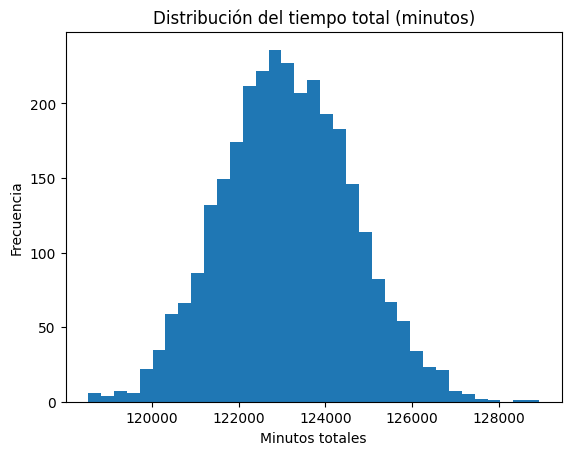

In [52]:
plt.figure()
plt.hist(result["totals_minutes"], bins=35)
plt.title("Distribución del tiempo total (minutos)")
plt.xlabel("Minutos totales")
plt.ylabel("Frecuencia")
plt.show()

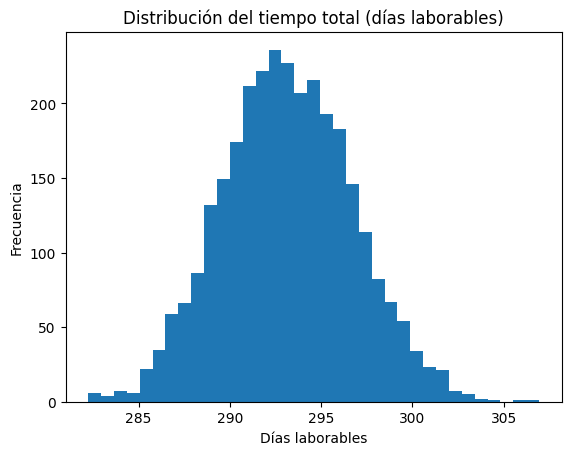

In [ ]:
plt.figure()
plt.hist(result["totals_minutes"] / MIN_Jornada, bins=35)
plt.title("Distribución del tiempo total (días laborables)")
plt.xlabel("Días laborables")
plt.ylabel("Frecuencia")
plt.show()

#HACER DIAGRAMA DE GANNT PARA UNA SIMULACION